In [77]:
import torch
from previous_chapters import GPTModel

GPT_CONFIG_124M={
    "vocab_size" : 50257,
    "context_length" : 256, # max_length
    "emb_dim" : 768,
    "n_heads" : 12,
    "n_layers" : 12,
    "drop_rate" : 0.1,
    "qkv_bias" : False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [78]:
import tiktoken
from previous_chapters import generate_text_simple

def text_to_token_ids(text,tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # 차원 추가, 여기선 배치 차원 추가
    return encoded_tensor

def token_ids_to_text(token_ids,tokenizer):
    flat = token_ids.squeeze(0) # 차원 제거, 여기선 배치 차원 제거
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding('gpt2')

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


In [79]:
inputs = torch.tensor([[16833, 3626, 6100], # evry effort moves
                        [40, 1107, 588]]) # I really like
targets = torch.tensor([[3626, 6100, 345],  # effort moves you
                         [1107, 588, 11311]]) # really like chocolate

with torch.no_grad(): #아직 훈련을 하지 않기 때문에, 그레이디언트 추적 끄기
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)
print(probas.shape)

token_ids = torch.argmax(probas, dim=-1, keepdim=False)
print("Token ID:\n", token_ids, token_ids.shape)

token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token ID:\n", token_ids, token_ids.shape)



torch.Size([2, 3, 50257])
Token ID:
 tensor([[16657,   339, 42826],
        [49906, 29669, 41751]]) torch.Size([2, 3])
Token ID:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]]) torch.Size([2, 3, 1])


In [80]:
print(f"첫 번째 샘플의 타깃:{token_ids_to_text(targets[0], tokenizer)}")
print(f"첫 번째 샘플의 출력:"
      f" {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

첫 번째 샘플의 타깃: effort moves you
첫 번째 샘플의 출력:  Armed heNetflix


In [81]:
text_idx = 0
target_probas_1 = probas[text_idx, [0,1,2], targets[text_idx]] # __getitem__
print("text 1: ", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0,1,2], targets[text_idx]] # __getitem__
print("text 2: ", target_probas_2)

text 1:  tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
text 2:  tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [82]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [83]:
avg_log_probas = torch.mean(log_probas) 
print(avg_log_probas) 

tensor(-10.7940)


In [84]:
neg_avg_log_probas = -1 * avg_log_probas # 이 크로스 엔트로피를 가능한 0에 가깝게 만드는 것이 목표 (보통 음의 로그 확률을 씀)
print(neg_avg_log_probas)
print("Logits shape:",logits.shape)
print("Target shape:",targets.shape)

tensor(10.7940)
Logits shape: torch.Size([2, 3, 50257])
Target shape: torch.Size([2, 3])


In [85]:
logits_flat = logits.flatten(0,1)
targets_flat = targets.flatten()
print("Flatten Logits:", logits_flat.shape) # (Batch * Seq, Vocab_size)
print("Flatten Target:", targets_flat.shape) # (Batch * Seq,)

Flatten Logits: torch.Size([6, 50257])
Flatten Target: torch.Size([6])


In [86]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)
perplexity = torch.exp(loss) 
print(perplexity) # 다음 토큰으로 생성할 후보 수가 48725

tensor(10.7940)
tensor(48725.8672)


In [87]:
file_path = "the-verdict.txt"
with open(file_path, 'r', encoding = "utf-8") as file:
    text_data=file.read()

total_char = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("# of char: ", total_char)
print("# of tokens: ", total_tokens)

# of char:  20479
# of tokens:  5145


In [88]:
from previous_chapters import create_dataloader_v1

torch.manual_seed(123)
train_ratio = 0.9
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M['context_length'],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last = True,
    shuffle = True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M['context_length'],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last = False,
    shuffle = False,
    num_workers=0
)

In [89]:
print("Train dataset: ")
for x, y in train_loader:
    print(x.shape, y.shape)

print("Validation dataset: ")
for x,y in val_loader:
    print(x.shape, y.shape)

Train dataset: 
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
Validation dataset: 
torch.Size([2, 256]) torch.Size([2, 256])


In [90]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0,1), target_batch.flatten()
    )
    return loss

In [91]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0
    if len(data_loader) == 0:
        return float("nan") # Not a Number
    elif num_batches is None:
        num_batches = len(data_loader) # num_batches가 지정되지 않으면 모든 배치를 순회
    else:
        num_batches = min(num_batches, len(data_loader)) # num_batches가 데이터 로더에 있는 배치 개수보다 크면 배치 횟수를 데이터 로더에 있는 총 배치 개수로 맞춤
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item() # 각 배치의 손실 합
        else:
            break
    return total_loss / num_batches # 모든 배치의 손실을 평균

device = torch.device("cuda" if torch.cuda.is_available() else "cpu" )
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
print("Train loss: ", train_loss)
print("Val loss: ", val_loss)

Train loss:  10.987583266364204
Val loss:  10.981106758117676


In [92]:
def train_model_simple(model, train_loader, val_loader,
                        optimizer, device, num_epochs,
                        eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], [] # 손실과 지금까지 처리한 토큰 수 추적용
    token_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # 이전 배치 반복에서 얻은 손실 그레이디언트 초기화
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward() # 손실 그레이디언트 계산
            optimizer.step() # 손실 그레이디언트를 사용하여 모델 가중치를 업데이트
            token_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0 : # 추가적인 평가 단계
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(token_seen)
                print(f"Epoch {epoch+1} (Step {global_step:06d}) : "
                      f"Train loss {train_loss:.3f},"
                      f"Val loss: {val_loss:.3f}"
                      )
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

In [93]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval() # 드랍아웃 비활성
    with torch.no_grad(): # 그레이디언트 추적 비활성
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches = eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device , num_batches = eval_iter
        )

    model.train()
    return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size = context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [94]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(), # parameters() 메서드 : 모델에 있는 훈련 가능한 모든 가중치 파라미터 리턴
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Epoch 1 (Step 000000) : Train loss 9.819,Val loss: 9.934
Epoch 1 (Step 000005) : Train loss 8.065,Val loss: 8.340
Every effort moves you,,,,,,,,,,,,.                                     
Epoch 2 (Step 000010) : Train loss 6.622,Val loss: 7.052
Epoch 2 (Step 000015) : Train loss 6.048,Val loss: 6.601
Every effort moves you, and,, and,,,,,,, and,.                                   
Epoch 3 (Step 000020) : Train loss 5.591,Val loss: 6.479
Epoch 3 (Step 000025) : Train loss 5.553,Val loss: 6.413
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and
Epoch 4 (Step 000030) : Train loss 5.177,Val loss: 6.367
Epoch 4 (Step 000035) : Train loss 4.987,Val loss: 6.379
Every effort moves you a a, and a a, and the a, and a. Gisburn, and a, and the of the of the of the a. I had the a, and a. I had the of the a of the of the of
Epoch 5 (Step 000040) : Train loss 4.351,Val loss: 6.276
Every effort moves you, I

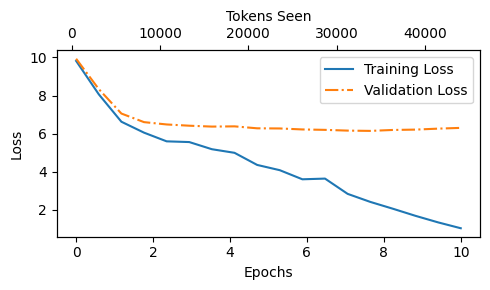

In [95]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5,3))
    ax1.plot(epochs_seen, train_losses, label="Training Loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation Loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny() # y축을 공유하는 두 번째 x축을 만듦
    ax2.plot(tokens_seen, train_losses, alpha=0) # 눈금을 정렬하기 위해 투명한 그래프를 만듦
    ax2.set_xlabel("Tokens Seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses)) #linspace(시작할 숫자, 끝날 숫자, 시작점부터 끝점까지 총 몇 개의 숫자로 쪼갤 것인지)
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [96]:
model.to("cpu")
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




In [97]:
vocab = {
    "closer" : 0,
    "every" : 1,
    "effort" : 2,
    "forward": 3,
    "inches" : 4,
    "moves" : 5,
    "pizza" : 6,
    "toward" : 7,
    "you" : 8,
}
inverse_vocab = {v:k for k, v in vocab.items()}
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item() # Tensor를 Python 숫자 데이터타입으로 변환
print(inverse_vocab[next_token_id])


forward


In [98]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [99]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item()
    for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} * {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 * closer
0 * every
0 * effort
582 * forward
2 * inches
0 * moves
0 * pizza
343 * toward


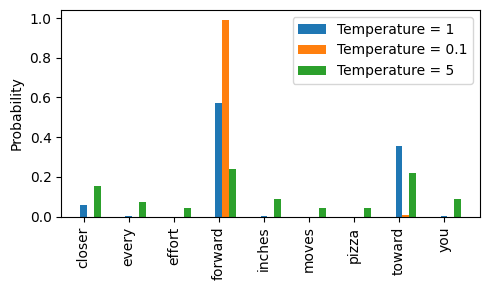

In [100]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

temperatures= [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5,3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x+i*bar_width, scaled_probas[i],
                    bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [101]:
# 연습문제 5-1

In [102]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k) # torch.topk return : logits, idx
print("Top-k Logits: ", top_logits)
print("Top-k Position: ", top_pos)

Top-k Logits:  tensor([6.7500, 6.2800, 4.5100])
Top-k Position:  tensor([3, 7, 0])


In [103]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1], # Top-k 토큰 중 마지막 토큰보다 로짓이 작은 토큰 찾기
    input=torch.tensor(float('-inf')), #찾은 토큰의 logit -inf 변경
    other=next_token_logits # 다른 모든 토큰은 원래 logit 유지
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [104]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [105]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:,-1,:]
        if top_k is not None: #top-k 샘플링으로 로짓을 필터링
            top_logits, _ = torch.topk(logits, top_k) 
            min_val = top_logits[:,-1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )

        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits,dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)

        else : # Temperature Sampling Not Used
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if idx_next == eos_id : # EOS토큰을 만나면 중단
            break

        idx =  torch.cat((idx,idx_next), dim=1)

    return idx

torch.manual_seed(123)
token_ids = generate(model,text_to_token_ids("Every effort moves you", tokenizer), max_new_tokens=15, context_size=GPT_CONFIG_124M['context_length'], top_k=25, temperature=1.4)
print("Output: ", token_ids_to_text(token_ids, tokenizer))

Output:  Every effort moves you in," she down surprise. Th--I felt nervous portrait by his knees


In [106]:
# 연습문제 5.2
# 연습문제 5.3

In [107]:
torch.save(model.state_dict(), "model.pth") # 모델의 층과 파라미터를 매핑한 딕셔너리 state_dict 저장
model=GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [108]:
torch.save({
    "model_state_dict" : model.state_dict(),
    "optimizer_state_dict" : optimizer.state_dict()},
"model_and_optimizer.pth")

ckpt = torch.load("model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(ckpt["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(ckpt["optimizer_state_dict"])
model.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [109]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rickiepark/"
    "llm-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x2889150c860>)

In [110]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


In [111]:
print("Setting: ", settings)
print("Params dictionary keys: ", params.keys())
print(params["wte"])
print("Token Embedding Weight Shape: ", params["wte"].shape)


Setting:  {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Params dictionary keys:  dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])
[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token Embedding Weight Shape:  (50257, 768)


In [112]:
# 딕셔너리로 모델 설정을 저장합니다.
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# 기본 설정을 특정 값으로 업데이트합니다.
model_name = "gpt2-small (124M)"  # 모델 이름
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True}) #편향 벡터는 모델의 성능을 향상시키지 못해 불필요하기 때문에, LLM에서 더이상 널리 쓰이지 않음.

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

In [113]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"크기가 다릅니다. left: {left.shape},"
                          "right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))



In [114]:
import numpy as np

def load_weights_into_gpt(gpt, params): # 위치 임베딩과 토큰 임베딩의 가중치를 params의 값으로 설정
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])): # 모델의 트랜스포머 블록 순회
        q_w, k_w, v_w = np.split(  #np.split을 사용하여 어텐션 가중치와 편향 가중치를 쿼리 키 값 세 부분으로 분리
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"]) # OpenAI의 원본 GPT2 모델은 토큰 임베딩의 가중치를 출력층에 재사용하여 전체 파라미터 개수를 절감하는 가중치 묶기 사용
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

load_weights_into_gpt(gpt, params)
gpt.to(device);
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트:
 Every effort moves you as far as the hand can go until the end of your turn unless something interrupts your control flow. As you may observe I


In [ ]:
#연습문제 5.5
#연습문제 5.6